In [1]:
import socket
import time
import struct
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython import display


In [2]:
def recv_n_bytes(s, n):
    buffer = bytearray()
    while len(buffer) < n:
        data = s.recv(n - len(buffer))
        if not data:
            if len(buffer) > 0:
                return buffer
            return None
        buffer.extend(data)
    return buffer

In [3]:
class Device:
    def __init__(self):
        self.fig, self.ax = plt.subplots(figsize=(10,4))
        display.clear_output()
        
        self.v = 0.0
        self.t = 0.0
        
        self.times, self.vels = [], []

    def add_dp(self, acc, t):
        if self.t > 0:
            dt = (t - self.t) / 1000.0
    
            self.v += 9.8 * (acc - 1.0071216108364667) * dt
            self.t = t
            self.times.append(t)
            self.vels.append(self.v)
        else:
            self.t = t

    def plot(self):
        display.clear_output(wait=True)
        self.ax.clear()

        self.ax.set_xlabel('time (s)')
        self.ax.set_ylabel('vel, (m/s)')
        self.ax.plot(self.times, self.vels)
        display.display(self.fig)

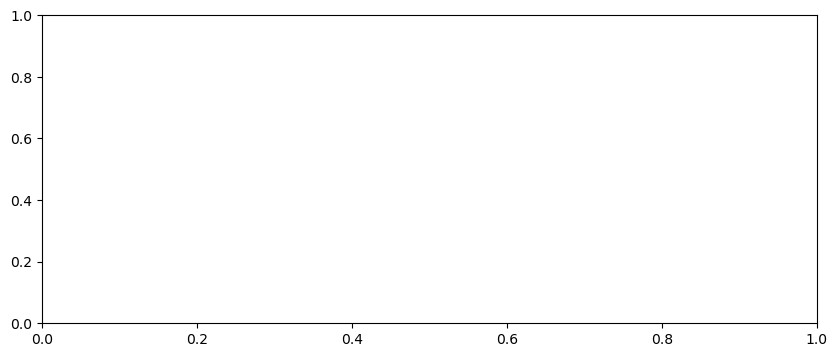

In [9]:
d = Device()

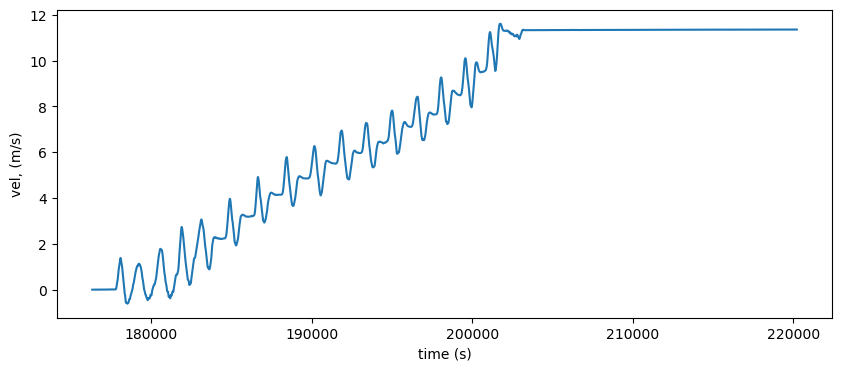

In [10]:
dps = []
host = "192.168.0.100"
port = 12345
i = 0

server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
server.bind((host, port))
server.listen(1)

print(f"Listening on {host}:{port}...")

client_socket, client_address = server.accept()
print(f"Connection from {client_address}")

start = time.time()
while True:
    i += 1
    data = recv_n_bytes(client_socket, 8)
    acc, t = struct.unpack('fI', data)
    d.add_dp(acc, t)
    if i % 10 == 0:
        d.plot()
        

client_socket.close()
server.close()

In [8]:
df = pd.DataFrame(dps, columns=['acc', 't'])

In [ ]:
df

In [ ]:
df['acc'].mean()

In [ ]:
df['acc'].mean(), df['acc'].std()

In [ ]:
data

In [ ]:
pd.DataFrame(np.stack([acc[1000:4000], t[1000:4000]]).T, columns=['acc', 't']).to_csv('teddy_ohp.csv', index=False)

In [ ]:
acc, t = np.array(dps).T

In [ ]:
acc.mean()

In [ ]:
dt = np.diff(t) / 1000
acc = acc[1:] * 9.8

In [ ]:
slope

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
vel = (acc * dt).cumsum()

In [ ]:
plt.plot((acc * dt).cumsum())

In [ ]:
vel = vel[1000:4000]

In [ ]:
x = np.arange(len(vel))
coefficients = np.polyfit(x, vel, 1)
slope = coefficients[0]
intercept = coefficients[1]
norm_v = vel - (slope * x + intercept)

In [ ]:
len(dt)

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(dt.cumsum()[1000:4000], norm_v)
ax.set_xlabel('s')
ax.set_ylabel('m/s')
fig.savefig('ohp.png')

In [ ]:
4*7

In [ ]:
client_socket.close()
server.close()

In [ ]:
df = pd.DataFrame(dps, columns=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z', 'time'])

In [ ]:
df[['adj_acc_x', 'adj_acc_y', 'adj_acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].mean()

In [ ]:
df.to_csv('rot_test.csv')

In [ ]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(12,8))
axs[0,0].plot(df['gyr_x'])
axs[0,1].plot(df['gyr_y'])
axs[0,2].plot(df['gyr_z'])
axs[1,0].plot((df['gyr_x'] * 100/1000).cumsum())
axs[1,1].plot((df['gyr_y'] * 100/1000).cumsum())
axs[1,2].plot((df['gyr_z'] * 100/1000).cumsum())

In [ ]:
1/((4736 / 60) / 1000)

In [ ]:
1/((5534 / 60) / 1000)

In [ ]:
def crt_to_plr(xyz):
    plr = np.zeros_like(xyz)
    xy = xyz[:,0]**2 + xyz[:,1]**2
    plr[:,0] = np.sqrt(xy + xyz[:,2]**2)
    plr[:,1] = np.arctan2(xyz[:,1], xyz[:,0])
    plr[:,2] = np.arctan2(np.sqrt(xy), xyz[:,2])
    return plr

In [ ]:
def plr_to_crt(rtp):
    crt = np.zeros_like(rtp)
    crt[:,0] = rtp[:, 0] * np.cos(rtp[:, 1]) * np.sin(rtp[:, 2])
    crt[:,1] = rtp[:, 0] * np.sin(rtp[:, 1]) * np.sin(rtp[:, 2])
    crt[:,2] = rtp[:, 0] * np.cos(rtp[:, 2])
    return crt
    

In [ ]:
def sub_grav(xyz):
    plr = crt_to_plr(xyz)
    plr[:,0] = plr[:,0] - 1.0
    return plr_to_crt(plr)

In [ ]:
df = pd.read_csv('180cal.csv')

In [ ]:
df[['adj_acc_x', 'adj_acc_y', 'adj_acc_z']] = sub_grav(df[['acc_x', 'acc_y', 'acc_z']].values)

In [ ]:
cal_df= df

In [ ]:
df.to_csv('./180cal.csv', index=False)

In [ ]:
data = df[['adj_acc_x', 'adj_acc_y', 'adj_acc_z']].values

In [ ]:
vel = (data.cumsum(axis=-1) ** 2.0).sum(axis=-1) ** 0.2

In [ ]:
fig, ax = plt.subplots()
ax.plot(np.arange(0, len(vel) / 100, 0.01), vel)

In [ ]:
cal_df.to_csv('./cal60.csv')

In [ ]:
1 / (5426 / 60)

In [ ]:
df = cal_df

In [ ]:
df['time'] = np.arange(len(df), dtype=float) / (5426 / 60) * 1000

In [ ]:
df

In [ ]:
def get_dt(col):
    return ((col - col.shift(1)).fillna(0) + (col.shift(-1) - col).fillna(0)) / 2
(((df[['adj_acc_x', 'adj_acc_y', 'adj_acc_z']] * (df[['time']].apply(get_dt) / 1000).values)).cumsum() ** 2).sum(axis=1) ** 2

In [ ]:
((df[['adj_acc_x', 'adj_acc_y', 'adj_acc_z']] * 1 / (5426 / 60)).cumsum() ** 2).sum(axis=1) ** 2

In [ ]:
df[['adj_acc_x', 'adj_acc_y', 'adj_acc_z']].iloc[0] * 0.005529

In [ ]:
df[['time']].diff().fillna(0).apply(lambda x: (x + x.shift(-1, fill_value=0))/2/1000)

In [ ]:
df['time'] = df['time'] - 110.123

In [ ]:
df[['time']].diff().fillna(0).apply(lambda x: (x + x.shift(-1, fill_value=0))/2/1000)

In [ ]:
t = pd.DataFrame([1,2,3,4])

In [ ]:
dt = (t[0].diff().fillna(0) + dt.shift(-1, fill_value=0)) / 2

In [ ]:
dt = t.diff().fillna()

In [ ]:
t[0].apply(lambda t: (t - t.shift(1)).fillna(0) + (t.shift(-1) - t).fillna(0))

In [ ]:
t - t.shift(1, fillna=)

In [ ]:
dt.shift(-1, fill_value=0)

In [ ]:
df['vel'] = (df['adj_acc_x']*)